# Volatility smile, price curves, and IV surface

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as sci
from datetime import datetime
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
%matplotlib inline
# %matplotlib ipympl

In [24]:
# Black-Scholes equations for future use

def d1(S, K, T, r, sigma, q):
    return (np.log(S/K) + (r - q + (sigma **2 / 2)) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, sigma, q):
    return d1(S, K, T, r, sigma, q) - sigma * np.sqrt(T)


def call_price(S, K, T, r, sigma, q):
    return sci.norm.cdf(d1(S, K, T, r, sigma, q))*S*np.exp(-q*T) - sci.norm.cdf(d2(S, K, T, r, sigma, q))*K*np.exp(-r*T)

In [25]:
# constants

TICKER_NAME = "MSTR"
OPTION_DATE = '2026-12-18'
VOLUME_FILTER = 1
OPENINTEREST_FILTER = 111


ticker = yf.Ticker(TICKER_NAME)


# Later implements using price on date of trade
S = ticker.fast_info['last_price']


expiry = datetime.strptime(OPTION_DATE, '%Y-%m-%d')
print(f"Pull option date from {ticker.options}")
today = datetime.today()
T = (expiry - today).days / 365

# Rough r value from TBills
tbill = yf.Ticker("^IRX")
r = tbill.fast_info['last_price'] / 100

# Tweak for stock dividend - 0 for nothing
q = 0.013

print(f"S = {S}, T = {T}, r = {r}, q = {q}")

calls = ticker.option_chain(OPTION_DATE).calls
puts = ticker.option_chain(OPTION_DATE).puts

print(f"Num calls = {len(calls)}, Num puts = {len(puts)}")


filtered_calls = calls[(calls['volume'] > VOLUME_FILTER) & (calls['openInterest'] > OPENINTEREST_FILTER)]
filtered_puts = puts[(puts['volume'] > VOLUME_FILTER) & (puts['openInterest'] > OPENINTEREST_FILTER)]

print(f"(Filtered) Num calls = {len(filtered_calls)}, Num puts = {len(filtered_puts)}")


oldest_trade = min(min(filtered_puts['lastTradeDate']), min(filtered_calls['lastTradeDate']))

print(f"Oldest trade date = {oldest_trade}")
ticker_history = yf.download(TICKER_NAME, start=oldest_trade, end=None)


Pull option date from ('2026-05-15', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-26', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')
S = 183.5050048828125, T = 0.6, r = 0.036069998741149904, q = 0.013
Num calls = 129, Num puts = 122
(Filtered) Num calls = 57, Num puts = 44
Oldest trade date = 2026-04-17 14:09:09+00:00


[*********************100%***********************]  1 of 1 completed


In [26]:

# Logic for accessing the daily stock prices, since some trades happen on previous (and different) days
ticker_history.columns = ticker_history.columns.droplevel(1)
ticker_history['date'] = ticker_history.index.date
filtered_calls['date'] = filtered_calls['lastTradeDate'].dt.date
filtered_calls = filtered_calls.merge(ticker_history[['date', 'Close']], on='date')


call_prices = call_price(filtered_calls['Close'], filtered_calls['strike'], T, r, filtered_calls['impliedVolatility'], q)

mid_prices = (filtered_calls['bid'].values.flatten() + filtered_calls['ask'].values.flatten())/2

difference = call_prices - mid_prices

print(f"Mean difference = {np.mean(difference)}")

Mean difference = 1.298238071854591


/tmp/ipykernel_12938/721917105.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_calls['date'] = filtered_calls['lastTradeDate'].dt.date


/tmp/ipykernel_12938/1246110560.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


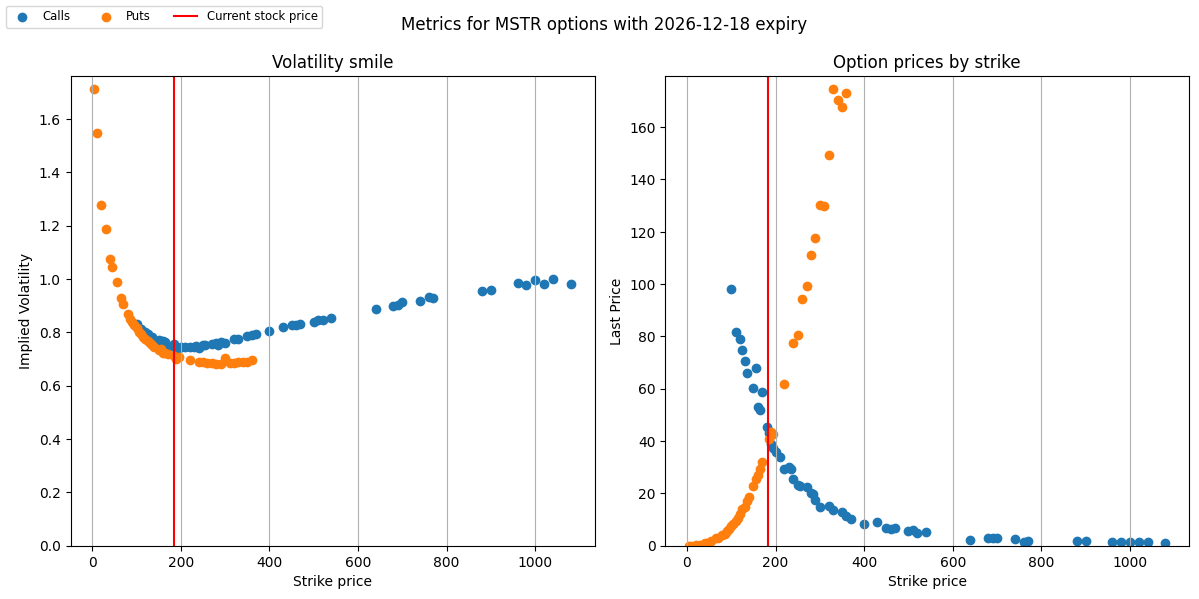

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

call_handle = ax1.scatter(filtered_calls['strike'], filtered_calls['impliedVolatility'], label="Calls")
put_handle = ax1.scatter(filtered_puts['strike'], filtered_puts['impliedVolatility'], label="Puts")
spot_handle = ax1.axvline(S, color='red', label="Current stock price")
ax1.set_ylim(bottom=0, top=max(filtered_puts['impliedVolatility'])+0.05)
ax1.grid(axis='x')
ax1.set_xlabel("Strike price")
ax1.set_ylabel("Implied Volatility")
ax1.set_title(f"Volatility smile")

ax2.scatter(filtered_calls['strike'], filtered_calls['lastPrice'])
ax2.scatter(filtered_puts['strike'], filtered_puts['lastPrice'])
ax2.axvline(S, color='red')
ax2.set_ylim(bottom=0, top=max(filtered_puts['lastPrice'])+5)
ax2.grid(axis='x')
ax2.set_xlabel("Strike price")
ax2.set_ylabel("Last Price")
ax2.set_title(f"Option prices by strike")

# ax3.scatter(filtered_calls['lastPrice'], filtered_calls['impliedVolatility'])
# ax3.scatter(filtered_puts['lastPrice'], filtered_puts['impliedVolatility'])
# ax3.set_ylim(bottom=0, top=max(filtered_puts['impliedVolatility'])+0.05)
# ax3.grid(axis='x')
# ax3.set_xlabel("Last Price")
# ax3.set_ylabel("Implied volatility")
# ax3.set_title(f"Volatility by price")

fig.legend(handles=[call_handle, put_handle, spot_handle], labels=["Calls", "Puts", "Current stock price"], loc='upper left', fontsize="small", ncol=3)
fig.suptitle(f"Metrics for {TICKER_NAME} options with {OPTION_DATE} expiry")
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.savefig("Metrics.png")
fig.show()

# Plotting an implied volatility surface

In [28]:
def prep_the_data():

    # Pull options data for multiple expiries
    all_calls = []
    all_puts = []

    for expiry_date in ticker.options:
        try:
            chain = ticker.option_chain(expiry_date)
            calls = chain.calls.copy()
            puts = chain.puts.copy()
            
            # Calculate time to expiry in years
            expiry = datetime.strptime(expiry_date, '%Y-%m-%d')
            T = (expiry - today).days / 365
            
            # Add T and expiry columns
            calls['T'] = T
            calls['expiry'] = expiry_date
            puts['T'] = T
            puts['expiry'] = expiry_date
            
            all_calls.append(calls)
            all_puts.append(puts)
        except Exception as e:
            print(f"Error fetching data for {expiry_date}: {e}")

    # Combine all calls and puts into one big DataFrame
    big_calls_df = pd.concat(all_calls, ignore_index=True)
    big_puts_df = pd.concat(all_puts, ignore_index=True)

    big_filtered_calls = big_calls_df[(big_calls_df['volume'] > VOLUME_FILTER) & (big_calls_df['openInterest'] > OPENINTEREST_FILTER)]
    big_filtered_puts = big_puts_df[(big_calls_df['volume'] > VOLUME_FILTER) & (big_calls_df['openInterest'] > OPENINTEREST_FILTER)]

    print(len(big_filtered_calls), len(big_filtered_puts), len(big_calls_df), len(big_puts_df))
    return big_filtered_calls, big_filtered_puts

In [29]:
def plot_the_thing():
    big_filtered_calls, big_filtered_puts = prep_the_data()
    # Filter expiries with <20 options at plotting stage
    calls_count = big_filtered_calls.groupby('expiry').size()
    puts_count = big_filtered_puts.groupby('expiry').size()
    valid_expiries = calls_count[calls_count >= 50].index.union(puts_count[puts_count >= 50].index)
    plot_calls = big_filtered_calls[big_filtered_calls['expiry'].isin(valid_expiries)]
    plot_puts = big_filtered_puts[big_filtered_puts['expiry'].isin(valid_expiries)]
    plot_puts = plot_puts[plot_puts['strike'] < 800]  # Limit puts strike to < 800

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # For calls
    x_c = plot_calls['strike']
    y_c = plot_calls['T']
    z_c = plot_calls['impliedVolatility']

    xi = np.linspace(x_c.min(), x_c.max(), 100)
    yi = np.linspace(y_c.min(), y_c.max(), 100)
    XI, YI = np.meshgrid(xi, yi)
    ZI = griddata((x_c, y_c), z_c, (XI, YI), method='linear')
    ZI = np.where((ZI > 2) | (ZI < 0), np.nan, ZI)  # Exclude IV > 2

    ax.plot_wireframe(XI, YI, ZI, color='blue', alpha=0.7, label='Calls')

    # For puts
    x_p = plot_puts['strike']
    y_p = plot_puts['T']
    z_p = plot_puts['impliedVolatility']

    xi_p = np.linspace(x_p.min(), x_p.max(), 100)
    yi_p = np.linspace(y_p.min(), y_p.max(), 100)
    XI_p, YI_p = np.meshgrid(xi_p, yi_p)
    ZI_p = griddata((x_p, y_p), z_p, (XI_p, YI_p), method='linear')
    ZI_p = np.where((ZI_p > 2) | (ZI_p < 0), np.nan, ZI_p)  # Exclude IV > 2

    ax.plot_wireframe(XI_p, YI_p, ZI_p, color='red', alpha=0.7, label='Puts')

    ax.set_xlabel('Strike Price')
    ax.set_ylabel('Time to Expiry (Years)')
    ax.set_zlabel('Implied Volatility')
    ax.set_title('Implied Volatility Surface')
    ax.invert_yaxis()  # Flip the time to expiry axis
    ax.legend()

    plt.show()

/tmp/ipykernel_12938/1649607478.py:33: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  big_filtered_puts = big_puts_df[(big_calls_df['volume'] > VOLUME_FILTER) & (big_calls_df['openInterest'] > OPENINTEREST_FILTER)]


940 893 2092 1971


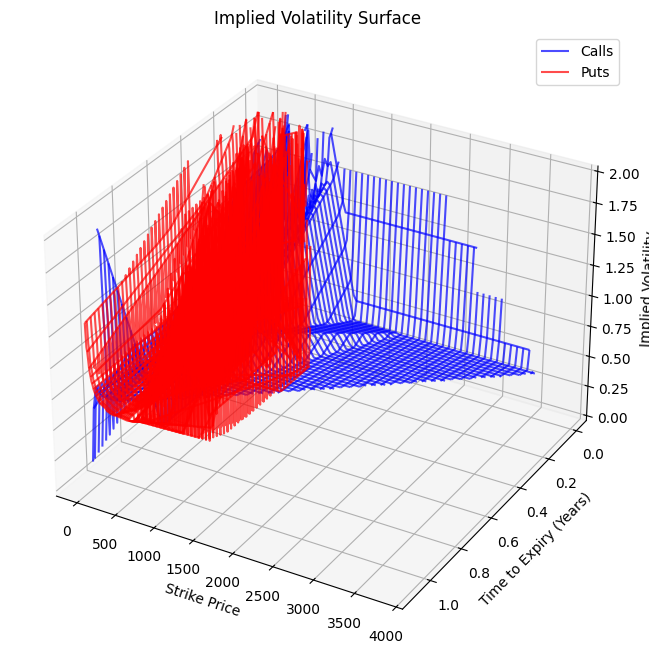

In [30]:
plot_the_thing()